# Assignment: week 3

The objectives of this assignment are:

1. to work with image data
2. to experiment with pretrained convnets

In [56]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

In [57]:
import matplotlib.pyplot as plt
import numpy as np
import keras
from keras import layers
from keras.models import Sequential, load_model
from keras.optimizers import Adam, SGD
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.applications.vgg16 import preprocess_input

## Data preparation

In [58]:
batch_size = 32
img_size = (32, 32)

train_dir = os.path.abspath("../datasets/CIFAR-10-images/train")
test_dir = os.path.abspath("../datasets/CIFAR-10-images/test")

train_dataset, validation_dataset = keras.utils.image_dataset_from_directory(
    train_dir,
    batch_size=batch_size,
    image_size=img_size,
    label_mode="categorical",
    validation_split=0.2,
    subset="both",
    seed=123
)

test_dataset = keras.utils.image_dataset_from_directory(
    test_dir,
    batch_size=batch_size,
    image_size=img_size,
    label_mode="categorical"
)

num_classes = len(train_dataset.class_names)

Found 50000 files belonging to 10 classes.
Using 40000 files for training.
Using 10000 files for validation.
Found 10000 files belonging to 10 classes.


In [59]:
conv_base = keras.applications.vgg16.VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(32, 32, 3)
)
conv_base.trainable = False

In [60]:
def extract_features(dataset):
    features = []
    labels = []

    for images, batch_labels in dataset:
        preprocessed = keras.applications.vgg16.preprocess_input(images)
        batch_features = conv_base(preprocessed, training=False)
        features.append(batch_features)
        labels.append(batch_labels)

    return np.concatenate(features), np.concatenate(labels)


train_features, train_labels = extract_features(train_dataset)
val_features, val_labels = extract_features(validation_dataset)
test_features, test_labels = extract_features(test_dataset)

In [ ]:
model = keras.Sequential([
    layers.Flatten(input_shape=train_features.shape[1:]),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

c:\Users\tontt\anaconda3\envs\keras\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [77]:
opt = Adam()
model.compile(loss="categorical_crossentropy",
              optimizer=opt,
              metrics=["accuracy"])

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,042 (132.98 KB)

 Trainable params: 34,042 (132.98 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
callbacks = [
    ModelCheckpoint(
        filepath="feature_extraction_without_data_augmentation.keras",
        save_best_only=True,
        monitor="val_loss"
    ),
    EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True)
]

In [79]:
history = model.fit(
    train_features,
    train_labels,
    epochs=30,
    validation_data=(val_features, val_labels),
    callbacks=callbacks
)

Epoch 1/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.1797 - loss: 2.6967 - val_accuracy: 0.3990 - val_loss: 1.8030
Epoch 2/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.3352 - loss: 1.8372 - val_accuracy: 0.5047 - val_loss: 1.4603
Epoch 3/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4030 - loss: 1.6432 - val_accuracy: 0.5434 - val_loss: 1.3616
Epoch 4/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.4460 - loss: 1.5362 - val_accuracy: 0.5744 - val_loss: 1.2868
Epoch 5/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.4807 - loss: 1.4613 - val_accuracy: 0.5921 - val_loss: 1.2339
Epoch 6/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.5070 - loss: 1.4079 - val_accuracy: 0.6020 - val_loss: 1.2174
Epoch 7/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5206 - loss: 1.3721 - val_accuracy: 0.6124 - val_loss: 1.1732
Epoch 8/30
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5425 - loss: 1.3284 - 

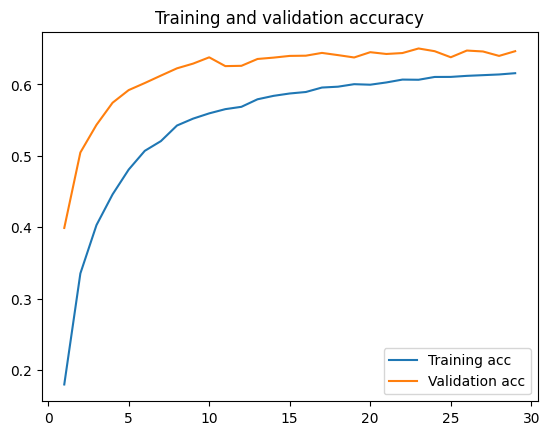

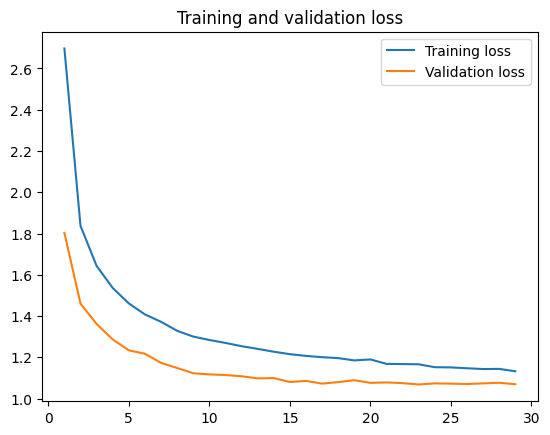

In [80]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc)+1)

plt.plot(epochs, acc, label='Training acc')
plt.plot(epochs, val_acc, label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()        

plt.plot(epochs, loss, label='Training loss')
plt.plot(epochs, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()

In [81]:
test_loss, test_acc = model.evaluate(test_features, test_labels)
print(f"Test accuracy: {test_acc:.3f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6430 - loss: 1.0716
Test accuracy: 0.643
